## SDK migration

`bigdata-client` and `bigdata-research-tools` are removed. Use REST (`BIGDATA_API_KEY`) / `bigdata-smart-batching` / OpenAI. Pass company CSVs (`RP_ENTITY_ID`, `COMPANY_NAME`) instead of watchlists. See [Thematic_Screener_CLI](../Thematic_Screener_CLI/) and [MIGRATION_PATTERNS.md](../MIGRATION_PATTERNS.md).


# ⚠️ SDK Migration Notice

**This notebook has been migrated off `bigdata-client` and `bigdata-research-tools`.**

- Use `src/bigdata_rest.py` and `src/search_helper.py` for API access
- Company universes are CSV files with `RP_ENTITY_ID` and `COMPANY_NAME` columns
- See `README.md` for updated setup instructions

# Credit Ratings Monitoring
## Automated Detection and Analysis of Credit Rating Events
This workflow demonstrates the capabilities of Bigdata to monitor specific events. In this example, we track credit ratings news for a Company and extract relevant features to track changes over time.

## Why It Matters
Credit rating changes or outlook revisions can have immediate effects on corporate bond spreads, equity valuations, and counterparty risk assessments. For traders, portfolio managers, and credit analysts, staying ahead of these developments is critical to anticipate market reactions and adjust exposure before the news is fully priced in.

## What It Does
This workflow systematically detects, labels, and summarizes event-related news for a selected watchlist of companies and entities using the Bigdata API for content retrieval and large language models for feature extraction. By customizing the prompts, keywords, and parameters, this framework can be adapted to monitor any type of corporate event or regulatory development - from credit ratings and earnings announcements to regulatory changes and strategic developments. The output includes both structured datasets and analytical reports for monitoring or backtesting.

## How It Works
The workflow implements a four-step agentic pipeline built on Bigdata API:

- **Content Retrieval & Enhancement**: Search for entities and event-specific keywords using the Bigdata Search API. Run queries over configurable time windows with parallel processing, collecting raw content with metadata and enriching results with surrounding context.

- **Feature Extraction & Validation**: Use LLM-powered analysis to identify entity relationships, extract structured event features, and validate classifications. The prompts can be customized to extract any necessary features for different event types and domains.

- **Advanced Analytics Generation**: Derive timestamped analytics with event-specific scoring and sentiment analysis tailored to your monitoring requirements.

- **Report generation**: Produce dated timelines of events with supporting quotes, source links, and exportable datasets for further analysis or integration into existing workflows.

## A Real World Use Case
This cookbook demonstrates the complete workflow through a practical example: tracking credit rating updates and outlook revisions for Tesla over a three-year period. You’ll learn how to transform unstructured rating-related news into structured insights that highlight rater-ratee relationships, analyst commentary, and market implications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When `bigdata-research-tools` makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

In [2]:
try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Load Credentials

In [4]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Import Required Libraries

Below is the Python code required for setting up our environment and importing necessary libraries.

In [5]:
import pandas as pd
from bigdata_smart_batching import plan_search, execute_search, deduplicate_documents

from src.knowledge_graph_manager import get_entity_ids
from src.search_helper import CATEGORY_BY_SCOPE
from src.feature_extractor import FeatureExtractor, clean_credit_ratings_features_dataset
from src.summary_generator import SummaryGenerator
from src.visuals import ReportVisualizer

print("\u2705 Migrated imports loaded (REST API + bigdata-smart-batching + OpenAI, no bigdata-client SDK)")


✅ Migrated imports loaded (REST API + bigdata-smart-batching + OpenAI, no bigdata-client SDK)


## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [6]:
import plotly.io as pio
import plotly.graph_objects as go

try:
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

interactive_plots = True  # Set to False to generate static plots

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our Trump reelection impact analysis results.

In [7]:
output_dir = "report"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/credit_ratings_monitor.csv"

## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [8]:
# No SDK client object is needed in the migrated workflow.
# src/bigdata_rest.py's BigdataRestClient (used internally by get_entity_ids / search_credit_ratings)
# reads BIGDATA_API_KEY directly from the environment when it is instantiated.
print("\u2705 REST API access ready (BIGDATA_API_KEY read from environment by src/bigdata_rest.py)")


✅ REST API access ready (BIGDATA_API_KEY read from environment by src/bigdata_rest.py)



## Defining Your Event Monitoring (Feature Extraction) Context and Parameters

To perform an event monitoring and feature extraction analysis, we need to define a few key parameters:

- **Company Names** (`company_names`): The set of companies to monitor events for (e.g. your portfolio or watchlist)

- **Rating Agencies Names** (`rating_agencies_names`): (Optional) The list of entities you want to be co-mentioned with your entities and events

- **Keywords** (`keywords`): The keywords characterizing the event

- **Time Period** (`start_date_query` and `end_date_query`): The date range over which to run the search

- **Frequency** (`frequency`): The frequency of the date ranges to search over. Supported values:
    - Y: Yearly intervals.
    - M: Monthly intervals.
    - W: Weekly intervals.
    - D: Daily intervals

- **Document Limit** (`document_limit`): The maximum number of documents to return per query to Bigdata API.

- **Batch Size** (`batch_size`): The number of entities to include in a single batched query.

- **Document Type** (`document_type`): Specify which documents to search over (transcripts, filings, news)

- **Model Selection** (`llm_model`): The AI model used for semantic analysis and topic classification

In [9]:
import datetime as dt

# ===== Context Definition ====
company_names = ['Tesla']
rating_agencies_names = ['S&P Global', 'Fitch Ratings Inc', "Moody's Corp"]
keywords = ['credit rating']  # Natural-language search text sent to the Bigdata Search API

# ===== Specify Time Range =====
# Cost control: narrow recent window instead of a multi-year backfill.
end_date_query = '2025-01-01'
start_date_query = '2021-09-01'

# ===== Query Configuration =====
document_type = 'news'      # 'news' | 'news_premium' | 'filings' | 'transcripts' | 'all'
chunk_percentage = 0.05      # cost control: real chunk volume for this narrow window is tiny (a few chunks)
requests_per_minute = 200

# ===== LLM Specification =====
model = 'gpt-5.6-luna'


## Portfolio Selection

Define your watchlist starting from the companies name. For the purpose of this example, the workflow selects **Tesla**. The Entity ID is retrieved by leveraging Bigdata.com’s Knowledge Graph.

In [10]:
companies, full_company_names, company_objects = get_entity_ids(company_names)

In order to boost the accuracy of the retrieval process, the workflow includes a selection of control entities in the queries, that is, entities that have to appear alongside Tesla in the search results. For the purpose of this example, the workflow selects the list of Credit Rating Agencies (CRAs), such as **S&P**, **Moody’s**, and **Fitch**.

In [11]:
rating_agencies, full_agencies_names, rating_agency_companies = get_entity_ids(rating_agencies_names)

## Content Retrieval from Bigdata Search API

The workflow searches news content using the Bigdata API to find articles mentioning Tesla, rating agencies, and credit rating keywords. The search runs across daily windows with parallel processing for efficiency.

The `search_enhanced` function retrieves not only the matching text chunks but also their surrounding context (previous and next paragraphs) to provide richer information for analysis.

Results are stored in the `contextualized_chunks` DataFrame for feature extraction.

In [12]:
# Only Tesla's RP_ENTITY_ID is passed as the search `universe` below -- Tesla is the ratee
# being rated, so it must be searched as the subject, not the rating agencies. The rating
# agency names are folded into the natural-language query text to bias retrieval toward
# chunks that mention them alongside Tesla.
#
# We call plan_search / execute_search / deduplicate_documents directly (the documented
# low-level bigdata-smart-batching API -- see ../MIGRATION_PATTERNS.md) instead of
# src/search_enhanced.py's simplified wrapper, because that wrapper hardcodes
# basket_filtered_entities=True, which would strip every entity out of each chunk except
# Tesla. We need basket_filtered_entities=False so that co-mentioned rating agencies
# (S&P/Moody's/Fitch) also survive as detected entities per chunk -- otherwise the
# rater-vs-ratee role detection below would never see a "rater" row and the pipeline would
# discard every row for lack of a rater entity.
id_to_name_full = {
    **dict(zip(companies, full_company_names)),
    **dict(zip(rating_agencies, full_agencies_names)),
}

query_texts = [
    f"{kw} outlook downgrade upgrade affirmed by {', '.join(full_agencies_names)}"
    for kw in keywords
]

category = CATEGORY_BY_SCOPE.get(document_type, CATEGORY_BY_SCOPE['all'])

rows = []
for query_text in query_texts:
    plan = plan_search(
        universe=companies,  # Tesla's RP_ENTITY_ID(s) -- the ratee/subject, not the rating agencies
        start_date=start_date_query,
        end_date=end_date_query,
        volume_query_mode='iterative',
        text=query_text,
        category=category,
    )
    raw_documents = execute_search(
        search_plan=plan,
        chunk_percentage=chunk_percentage,
        requests_per_minute=requests_per_minute,
        basket_filtered_entities=False,
    )
    for document in deduplicate_documents(raw_documents):
        headline = document.get('headline', '')
        timestamp = document.get('timestamp', '')
        url = document.get('url', '')
        source = document.get('source') or {}
        doc_id = document.get('id', '')
        for chunk_idx, chunk in enumerate(document.get('chunks') or []):
            text_chunk = chunk.get('text', '')
            # sentence_id must be shared by every entity row exploded from this SAME chunk
            # (assigned per-chunk, not per output row) so group_text_and_labels groups the
            # Tesla row and the Fitch/Moody's/S&P row from one chunk together -- otherwise
            # rater and ratee never co-occur in the same group.
            sentence_id = f"{doc_id}_{chunk_idx}"
            detected_ids = [str(e) for e in (chunk.get('entity_ids') or [])]
            # One row per recognized entity (Tesla or a rating agency) so the LLM
            # role-detection step below can tag some rows 'ratee' (Tesla) and others
            # 'rater' (the agency), instead of every row defaulting to Tesla only.
            relevant_ids = [eid for eid in detected_ids if eid in id_to_name_full] or ['']
            for entity_id in relevant_ids:
                rows.append({
                    'document_id': doc_id,
                    'sentence_id': sentence_id,
                    'headline': headline,
                    'timestamp_utc': timestamp,
                    'url': url,
                    'source_id': source.get('id', ''),
                    'source_name': source.get('name', ''),
                    'contextualized_chunk_text': text_chunk,
                    'text': text_chunk,
                    'relevance': chunk.get('relevance'),
                    'sentiment': chunk.get('sentiment'),
                    'entity_id': entity_id,
                    'entity_ids': detected_ids,
                    'entity_name': id_to_name_full.get(entity_id, entity_id),
                    'query': query_text,
                    'document_type': document_type,
                })

contextualized_chunks = pd.DataFrame(rows)

print(f"Retrieved {len(contextualized_chunks)} entity-mention row(s) from real search results")
contextualized_chunks.head()


2026-08-27 10:43:43,396 - INFO - Planning search for text: 'credit rating outlook downgrade upgrade affirmed by S&P Global Inc., Fitch Ratings Inc., Moody's Corp.'


2026-08-27 10:43:43,396 - INFO - Date range: 2021-09-01 to 2025-01-01


2026-08-27 10:43:43,397 - INFO - Using 1 entity IDs from inline list


2026-08-27 10:43:43,397 - INFO - Loaded 1 companies from universe


2026-08-27 10:43:43,400 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting


...

2026-08-27 10:43:46,961 - INFO - Search complete: 58 documents with 64 chunks retrieved in 1.30s


2026-08-27 10:43:46,961 - WARNING - Failed baskets: 1


2026-08-27 10:43:46,962 - INFO - Deduplicated: 58 unique documents from 58 total (chunks merged)


Retrieved 102 entity-mention row(s) from real search results


,document_id,sentence_id,headline,timestamp_utc,url,source_id,source_name,contextualized_chunk_text,text,relevance,sentiment,entity_id,entity_ids,entity_name,query,document_type
0,12FBE5245B8017D8DFAFF214BCEEC824,12FBE5245B8017D8DFAFF214BCEEC824_0,"Moody's upgrades Tesla's credit rating, declar...",2023-03-20T21:48:36,,B5235B,The Fly,Moody's Investors Service assigned a Baa3 long...,Moody's Investors Service assigned a Baa3 long...,0.266543,0.72,3461CF,"[9BA1F7, F4BA2E, 053803, 3461CF, 46FAFB, DD3BB...",Moody's Corp.,credit rating outlook downgrade upgrade affirm...,news
1,12FBE5245B8017D8DFAFF214BCEEC824,12FBE5245B8017D8DFAFF214BCEEC824_0,"Moody's upgrades Tesla's credit rating, declar...",2023-03-20T21:48:36,,B5235B,The Fly,Moody's Investors Service assigned a Baa3 long...,Moody's Investors Service assigned a Baa3 long...,0.266543,0.72,DD3BB1,"[9BA1F7, F4BA2E, 053803, 3461CF, 46FAFB, DD3BB...",Tesla Inc.,credit rating outlook downgrade upgrade affirm...,news
2,8E35C0E1D412DDE5CD1C1943F1E474B4,8E35C0E1D412DDE5CD1C1943F1E474B4_0,S&P Global Ratings Upgrades Tesla With Positiv...,2021-10-22T18:53:45,,9D69F1,MT Newswires,"02:53 PM EDT, 10/22/2021 (MT Newswires) -- S&P...","02:53 PM EDT, 10/22/2021 (MT Newswires) -- S&P...",0.247566,0.68,CFF97C,"[9CC31E, 39A0BA, CFF97C, 572F09, 46FAFB, DD3BB...",S&P Global Inc.,credit rating outlook downgrade upgrade affirm...,news
3,8E35C0E1D412DDE5CD1C1943F1E474B4,8E35C0E1D412DDE5CD1C1943F1E474B4_0,S&P Global Ratings Upgrades Tesla With Positiv...,2021-10-22T18:53:45,,9D69F1,MT Newswires,"02:53 PM EDT, 10/22/2021 (MT Newswires) -- S&P...","02:53 PM EDT, 10/22/2021 (MT Newswires) -- S&P...",0.247566,0.68,DD3BB1,"[9CC31E, 39A0BA, CFF97C, 572F09, 46FAFB, DD3BB...",Tesla Inc.,credit rating outlook downgrade upgrade affirm...,news
4,BC75ABAE3459DF8B0892F1C79406E04A,BC75ABAE3459DF8B0892F1C79406E04A_0,Tesla Debt Upgraded By 2 Slabs At Moody's: Why...,2022-01-25T11:00:39,https://www.benzinga.com/node/25200483?utm_cam...,5A5702,Benzinga,"On the margin front, Moody's expects an EBITDA...","On the margin front, Moody's expects an EBITDA...",0.174029,-0.36,3461CF,"[57502A, 8A982E, E988E9, A8527E, 9CC31E, 2E299...",Moody's Corp.,credit rating outlook downgrade upgrade affirm...,news


## Features Augmentation

### Entity Role Detection

The LLM agent is prompted to *label* the sentences extracted to identify the role played by the entities detected in each sentence, detecting raters and ratees. A unique identifier for the tuple of entity name, document headline, and augmented text is created and the content is sent to the LLM for role detection.

In [13]:
feature_extractor = FeatureExtractor(llm_model=model)

In [14]:
df_labeled = feature_extractor.assign_entity_roles(contextualized_chunks, 'contextualized_chunk_text', ['entity_name', 'headline'], action_type='detect')

2026-08-27 10:43:48,750 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:48,815 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:48,838 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:48,841 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:48,852 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 10:43:49,852 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:50,411 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:50,861 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:50,939 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:53,778 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


### Entity Role Validation

Subsequently, we prompt the LLM agent to *validate* the roles identified in the previous steps. We provide the original text, the label assigned and the motivation, and we instruct the LLM to either confirm or correct the role assigned to each entity.

In [15]:
df_labeled_valid = feature_extractor.assign_entity_roles(df_labeled, 'contextualized_chunk_text', ['entity_name','headline', 'motivation','label'], action_type='validate')

2026-08-27 10:43:55,240 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:55,243 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:55,318 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:55,321 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:55,331 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 10:43:56,547 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:56,885 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:57,048 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:43:57,268 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:02,584 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


### Features Augmentation

The LLM is instructed to augment the features related to long-term and short-term credit ratings, credit outlooks, and analysts’ comments in a multi-step approach leveraging three different prompts. The prompts can be customized to extract any necessary features.

**Prompt 1** is designed to extract the following: 
- **Credit Rating**: Extract the overall credit rating assigned to Tesla.
- **Credit Action**: Extract any change or affirmation of the credit rating assigned to Tesla, categorized as:
    - **Upgrade**: An improvement in the rating.
    - **Downgrade**: A decrease in the rating.
    - **Affirmed**: Rating confirmed with no change.
    - **Corrected**: Adjusted due to an error.
    - **Withdrawn**: The rating is removed.
    - **Reinstated**: A withdrawn rating is restored.
    
- **Credit Status**: Any additional information regarding the credit rating status, categorized as:
    - **Provisional Rating**: A preliminary rating.
    - **Matured or Paid in Full**: When the obligation reaches maturity.
    - **No Rating**: Rating declined or unavailable.
    - **Published**: Officially issued or announced.
    
- **Credit Outlook**: The credit outlook mentioned by the rater, and any related mention of the credit rating assessed in the coming weeks, months or years.
    - **Positive**: Suggests potential improvement.
    - **Negative**: Indicates potential downgrade.
    - **Stable**: No expected change.
    - **Developing**: Change possible based on future events.

- **Credit Watchlist**: Any mention of Tesla being placed in a credit watchlist for review of the credit rating. Labelled as:
    - **Watch**: The rating is on a watchlist.
    - **Watch Positive**: Potential upgrade.
    - **Watch Negative**: Suggests downgrade.
     - **Watch Removed**: No longer active.
     - **Watch Unchanged**: Status remains without change in expectation.

In [16]:
df_labeled_valid['date'] = pd.to_datetime(df_labeled_valid['timestamp_utc']).dt.date

In [17]:
exploded_df = feature_extractor.group_text_and_labels(df_labeled_valid, group_columns=['date', 'sentence_id', 'headline', 'source_name', 'contextualized_chunk_text', 'url'], role_column='validated_label', entity_column='entity_name')

In [18]:
features_extracted = {}

In [19]:
df_credit_ratings = feature_extractor.extract_single_feature(exploded_df, feature_type='credit_ratings', text_col='contextualized_chunk_text', additional_prompt_fields=['rater_entity', 'ratee_entity', 'unclear_entities'])
features_extracted['credit_ratings'] = df_credit_ratings

2026-08-27 10:44:04,210 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:04,216 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:04,242 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:04,252 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:04,294 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 10:44:06,395 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:06,603 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:07,033 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:07,440 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:08,073 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


**Prompt 2** is designed to extract the following: 
- **Short Term Credit Rating**: Any credit rating assigned to Tesla and specifically referred to a short-term debt instrument, if mentioned.
- **Long Term Credit Rating**: Any credit rating assigned to Tesla and specifically referred to a long-term debt instrument, if mentioned.
- **Debt Instrument**: The debt instruments under study.

In [20]:
df_debt_instruments = feature_extractor.extract_single_feature(exploded_df, feature_type='debt_instruments', text_col='contextualized_chunk_text', additional_prompt_fields=['rater_entity', 'ratee_entity', 'unclear_entities'])
features_extracted['debt_instruments'] = df_debt_instruments

2026-08-27 10:44:09,238 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:09,364 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:09,374 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:09,375 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:09,375 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 10:44:10,852 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:11,050 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:11,182 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:11,489 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:12,553 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


**Prompt 3** is designed to extract the following: 
- **Key Drivers**: Any motivating the credit rating or outlook decision, and influencing the credit quality of the ratee entity, including, but not limited to:
    - Cash flow generation (e.g. earnings, revenues, dividends, assets)
    - Insider trading, stock prices, stock picks
    - Capital structure changes (e.g. equity actions, acquisitions, mergers)
- **Forward Guidance**: Capture any forward guidance discussed regarding current or future credit ratings, including any potential changes or outlook updates.


In [21]:
df_drivers_guidance = feature_extractor.extract_single_feature(exploded_df, feature_type='drivers_guidance', text_col='contextualized_chunk_text', additional_prompt_fields=['rater_entity', 'ratee_entity', 'unclear_entities'])
features_extracted['drivers_guidance'] = df_drivers_guidance

2026-08-27 10:44:13,759 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:13,834 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:13,940 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:13,953 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:13,954 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 10:44:16,137 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:16,301 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:16,535 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:16,758 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:17,066 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [22]:
df_ext = feature_extractor._combine_features(exploded_df, features_extracted)

In [23]:
# company_objects are plain dicts returned by the REST knowledge-graph lookup
# (src/knowledge_graph_manager.get_entity_ids), so use dict access instead of attribute access.
name_to_id = {company.get('name'): company.get('id') for company in company_objects}
df_ext['ratee_entity_rp_entity_id'] = df_ext['ratee_entity'].map(name_to_id)
df_ext = df_ext.sort_values('date').reset_index(drop=True)


## Deriving a Structured Dataframe of Advanced Analytics

The workflow provides a timestamped dataframe of credit ratings news with advanced analytics generated through the feature augmentation process. This dataset can be exported in CSV for Excel for further analysis, such as validation, augmentation, or backtesting.

In [24]:
df_clean = clean_credit_ratings_features_dataset(df_ext)
df_clean.head(10)

,date,sentence_id,headline,source_name,url,contextualized_chunk_text,ratee_entity_rp_entity_id,ratee_entity,rater_entity,credit_rating,credit_outlook,credit_action,credit_status,credit_watchlist,short_term_credit_rating,long_term_credit_rating,debt_instrument,forward_guidance,key_drivers
0,2021-10-22,8E35C0E1D412DDE5CD1C1943F1E474B4_0,S&P Global Ratings Upgrades Tesla With Positiv...,MT Newswires,NaN,"02:53 PM EDT, 10/22/2021 (MT Newswires) -- S&P...",DD3BB1,Tesla Inc.,S&P Global Inc.,BB+,Positive,Upgrade,NaN,None,None,BB+,NaN,S&P expects Tesla's deliveries and earnings to...,Solid demand prospects; robust financial metri...
1,2022-01-25,BC75ABAE3459DF8B0892F1C79406E04A_0,Tesla Debt Upgraded By 2 Slabs At Moody's: Why...,Benzinga,https://www.benzinga.com/node/25200483?utm_cam...,"On the margin front, Moody's expects an EBITDA...",DD3BB1,Tesla Inc.,Moody's Corp.,NaN,NaN,Upgrade,NaN,None,None,NaN,corporate debt,Moody's expects Tesla's EBITDA margin to reach...,Expected margin expansion and stronger free ca...
2,2022-01-25,BC75ABAE3459DF8B0892F1C79406E04A_0,Tesla Debt Upgraded By 2 Slabs At Moody's: Why...,Benzinga,https://www.benzinga.com/node/25200483?utm_cam...,"On the margin front, Moody's expects an EBITDA...",DD3BB1,Tesla Inc.,S&P Global Inc.,NaN,NaN,NaN,NaN,None,None,NaN,NaN,Moody's expects Tesla's EBITDA margin to reach...,Expected margin expansion and stronger free ca...
3,2022-01-25,BC75ABAE3459DF8B0892F1C79406E04A_0,Tesla Debt Upgraded By 2 Slabs At Moody's: Why...,Benzinga,https://www.benzinga.com/node/25200483?utm_cam...,"On the margin front, Moody's expects an EBITDA...",DD3BB1,Tesla Inc.,Fitch Ratings Inc.,NaN,NaN,NaN,NaN,None,None,NaN,NaN,Fitch Ratings is expected to follow Moody's in...,No Fitch-specific rating drivers are stated. F...
4,2022-01-25,BC75ABAE3459DF8B0892F1C79406E04A_1,Tesla Debt Upgraded By 2 Slabs At Moody's: Why...,Benzinga,https://www.benzinga.com/node/25200483?utm_cam...,Credit ratings agency Moody's on Tuesday raise...,DD3BB1,Tesla Inc.,Moody's Corp.,Ba1,NaN,Upgrade,NaN,None,None,Ba1 (upgraded from Ba3),NaN,Moody's said Tesla is on track to maintain its...,Tesla's rapidly expanding presence across the ...
5,2022-01-25,CD69805567DD40D4BFF336FCBF7483AC_1,Moody's upgrades Tesla's corporate family rati...,Moody's,https://www.moodys.com/research/Moodys-upgrade...,Moody's anticipates liquidity to remain very g...,DD3BB1,Tesla Inc.,Moody's Corp.,NaN,Positive,NaN,NaN,None,None,NaN,$2.3 billion asset-based revolving credit faci...,"Moody's maintains a positive outlook, expectin...",Very good liquidity supported by a $16 billion...
6,2022-10-06,004E867FEF955AB692E35D33395653BD_0,Tesla credit rating upgraded 2 notches out of ...,Morningstar,https://www.morningstar.com/news/marketwatch/2...,Shares of Tesla Inc. rose 0.3% in afternoon tr...,DD3BB1,Tesla Inc.,S&P Global Inc.,BBB,Stable,Upgrade,NaN,None,None,BBB (raised from BB+),NaN,The rating outlook is stable.,S&P Global Ratings upgraded Tesla's rating to ...
7,2022-10-06,85AF5C0C495355ECA23942A910A1EAEA_0,Tesla Credit Rating Raised to Investment Grade...,Investing.com,https://za.investing.com/news/tesla-credit-rat...,"""The stable outlook reflects our expectation t...",DD3BB1,Tesla Inc.,S&P Global Inc.,NaN,Stable,NaN,NaN,None,None,NaN,NaN,S&P Global expects Tesla to maintain low debt ...,Low debt levels; solid market share; profitabi...
8,2022-10-06,85AF5C0C495355ECA23942A910A1EAEA_1,Tesla Credit Rating Raised to Investment Grade...,Investing.com,https://za.investing.com/news/tesla-credit-rat...,"Reuters\nTesla's (NASDAQ:) credit rating, inc...",DD3BB1,Tesla Inc.,S&P Global Inc.,BBB,Stable,Upgrade,NaN,None,None,BBB,Issuer credit rating and issue-level ratings,S&P Global upgraded Tesla's issuer credit and ...,The upgrade was driven by higher-than-expected...
9,2022-10-06,B5D13A1BA9AD10A91DFD0CC02D5B2337_0,Tesla Credit Rating Raised to Investment Grade...,Investing.com,https://ca.investing.com/news/stock-market-new...,TSLA -0.44% Add to/Remove from a Portf

In [25]:
df_clean.to_csv(export_path)

## Report Generation

In this step, the workflow summarizes the timeline of credit ratings news. Summarization is performed in two steps, removing duplicates and repeated events by generating daily summaries and generating a timeline that highlights new information.

Alongside the timeline of events, the workflow creates a final table which synthetizes the credit rating changes by rating agency, and visualizes it in an interactive plot.

In [26]:
summary_generator = SummaryGenerator(llm_model=model)

In [27]:
reports_dict = summary_generator.generate_report_by_entities(df = df_clean, entity_keys = companies, 
                                                             text_col = 'contextualized_chunk_text',
                                                             fields_for_summary = ['date', 'ratee_entity', 'headline','source_name','url','contextualized_chunk_text'])

Processing... (1/1)


2026-08-27 10:44:19,546 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:19,778 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:24,690 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:25,348 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 10:44:25,577 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generating Company Report...


2026-08-27 10:44:33,934 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Extracting Structured Data Table...


2026-08-27 10:44:39,796 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


## Save and Display Reports

Reports and tables can be customized and exported as HTML files for further analysis.

In [28]:
visualizer = ReportVisualizer(output_dir)

HTML report saved to: report/tesla_inc_credit_ratings_report.html
Figure saved to: report/tesla_credit_ratings_timeline.html


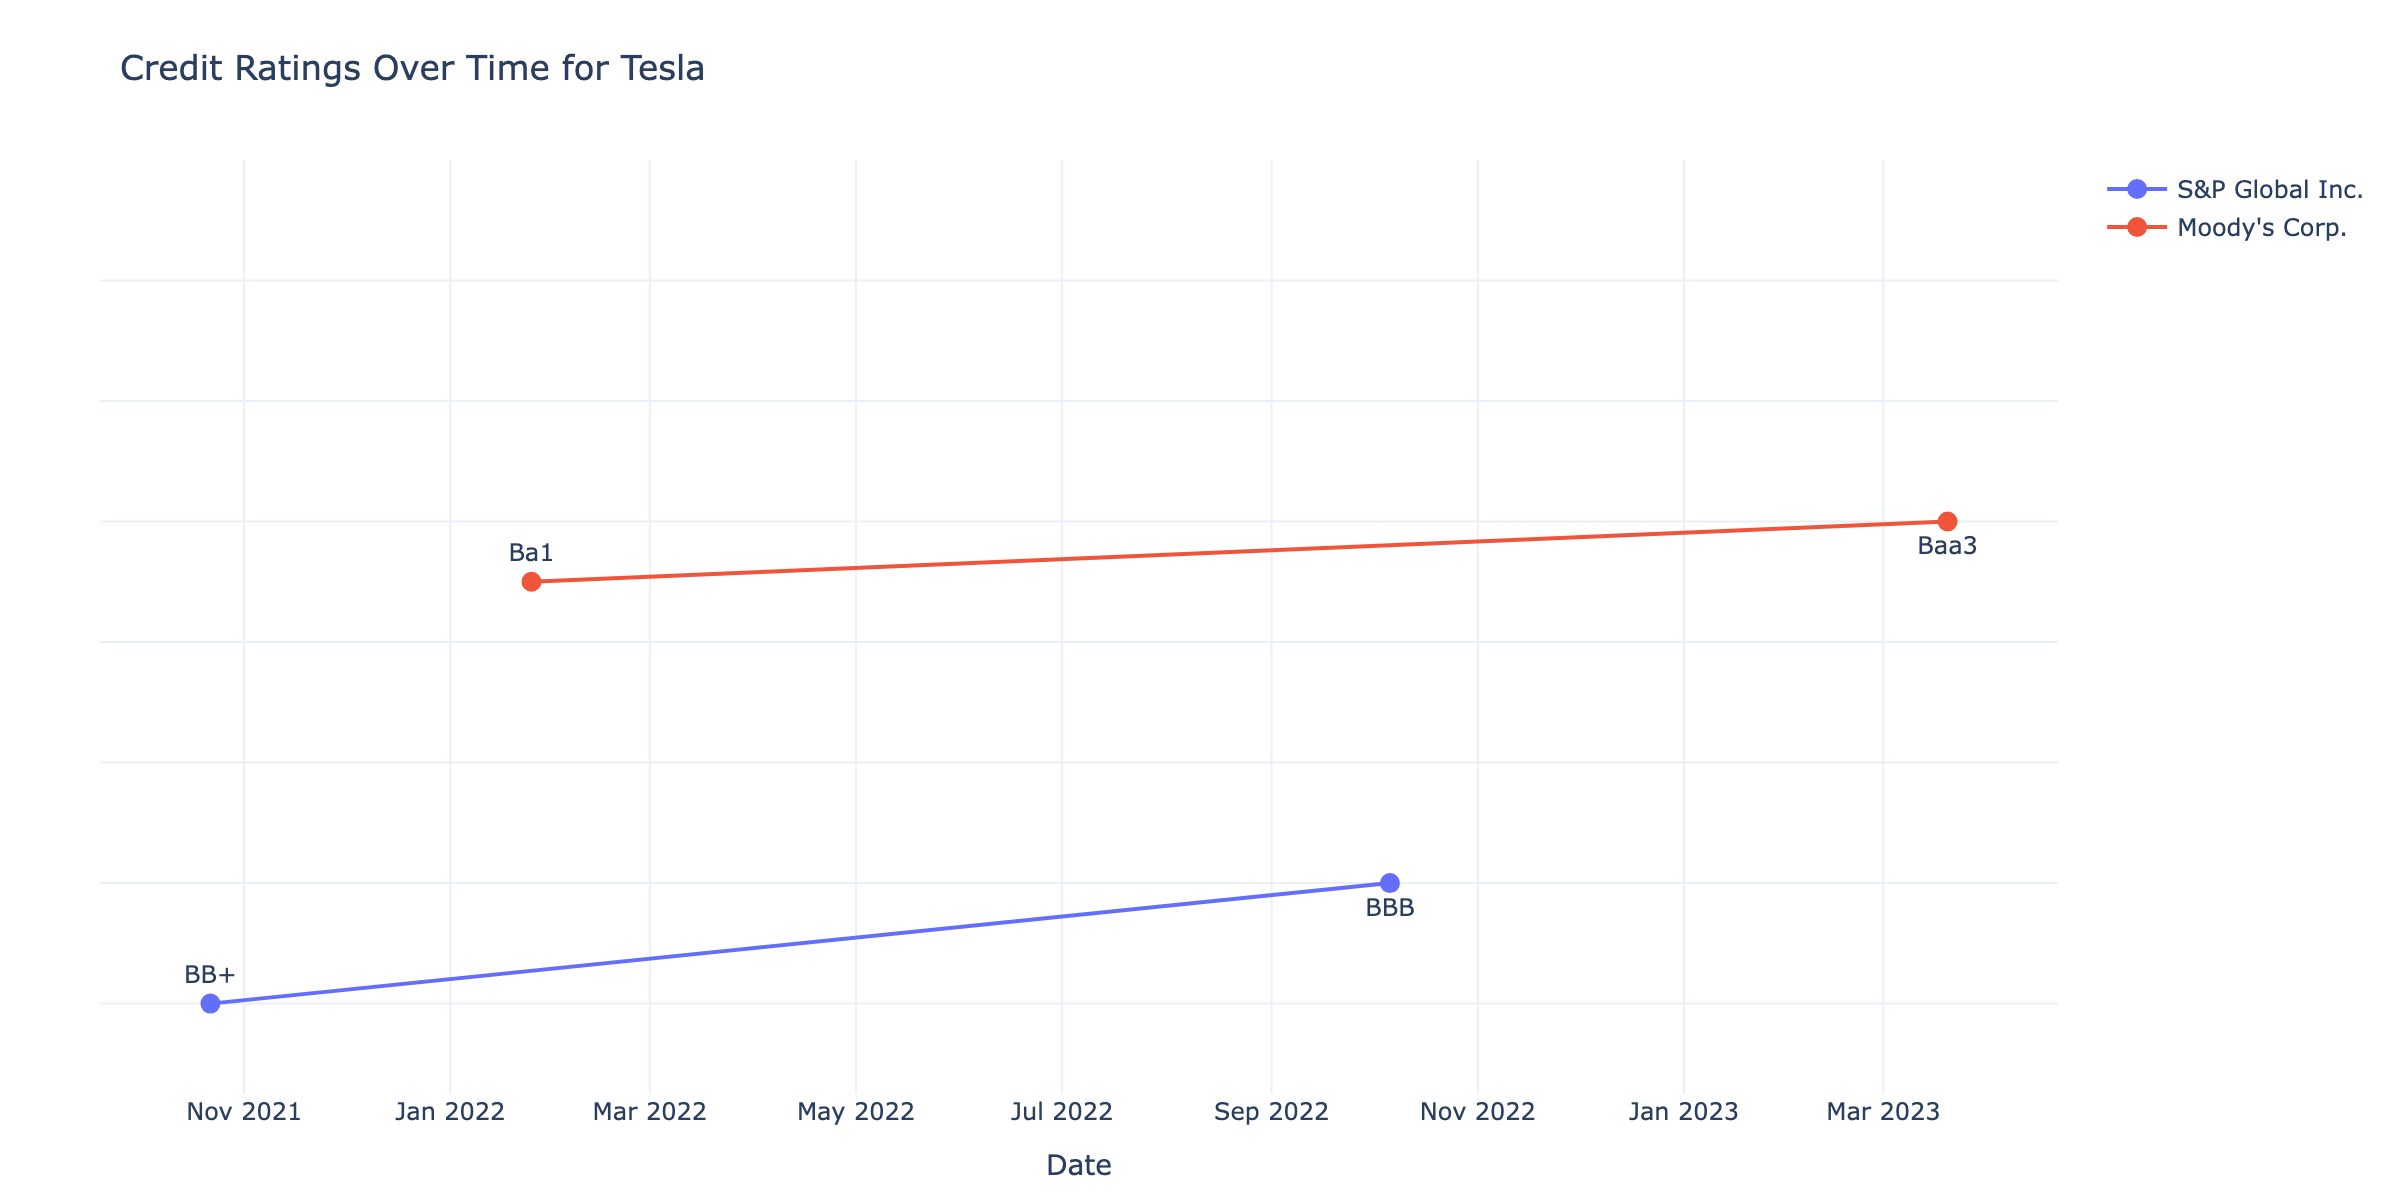

2026-08-27 10:44:39,980 - INFO - Chromium init'ed with kwargs {}


2026-08-27 10:44:39,982 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome


2026-08-27 10:44:39,983 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmp9_pz2eob.


2026-08-27 10:44:39,983 - INFO - Opening browser.


2026-08-27 10:44:39,984 - INFO - Temp directory created: /Users/franciscogomez/tmp/tmpio6bm7t6.


...

2026-08-27 10:44:42,420 - INFO - Exiting Kaleido/Choreo.


2026-08-27 10:44:42,503 - INFO - TemporaryDirectory.cleanup() worked.


2026-08-27 10:44:42,503 - INFO - shutil.rmtree worked.


2026-08-27 10:44:42,503 - INFO - Cancelling tasks.


2026-08-27 10:44:42,503 - INFO - Exiting Kaleido/Choreo.


In [29]:
import types

# src/visuals.py's ReportVisualizer.visualize_report_and_table() expects attribute access
# (company_object.id / .name), but company_objects are plain REST-API dicts -- wrap them in a
# SimpleNamespace so the existing visualization helper works unmodified.
for company in company_objects:
    company_ns = types.SimpleNamespace(**company)
    visualizer.visualize_report_and_table(reports_dict, company_ns, start_date_query, end_date_query)
